# Deputado federal: 2022 e 2026

Este notebook lê os dados abertos do TSE e a lista de deputados em exercício da Câmara.

As candidaturas exibidas são as **aptas** na eleição ordinária. Indeferidas, canceladas e inaptas ficam de fora.

A primeira execução baixa os arquivos oficiais. Candidatos e deputados atuais são leves. Votos de 2022 e prestação de contas são arquivos grandes; essas células podem demorar na primeira vez. O resultado fica em `dados/processados/` e as próximas execuções reaproveitam a tabela.

In [3]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

RAIZ = Path.cwd().resolve()
if not (RAIZ / "eleitoral").exists() and (RAIZ.parent / "eleitoral").exists():
    RAIZ = RAIZ.parent
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from eleitoral.analise import (
    comparar_disputas,
    cruzar_deputados,
    grafico_barras,
    resumo_por_partido,
    tabela_reais,
)
from eleitoral.camara import carregar_deputados_atuais
from eleitoral.config import DATA_CORTE_2026
from eleitoral.regras import formatar_inteiro
from eleitoral.tse import (
    carregar_candidatos,
    carregar_gastos_publicidade,
    carregar_votos,
    colunas_para_exibir,
)

pd.set_option("display.max_rows", 40)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 48)

print("Projeto:", RAIZ)
print("Corte da publicidade de 2026:", DATA_CORTE_2026.strftime("%d/%m/%Y"))
print("Para ver todas as linhas de uma tabela: pd.set_option('display.max_rows', None)")

Projeto: C:\Users\Luiz\Documents\analise-eleitoral
Corte da publicidade de 2026: 28/09/2026
Para ver todas as linhas de uma tabela: pd.set_option('display.max_rows', None)


## Candidatos a deputado federal em 2022, por partido

A tabela de cima é a contagem. A de baixo é a lista, ordenada por partido.

Arquivo local: consulta_cand_2022.zip
Lendo consulta_cand_2022_BRASIL.csv
Tabela salva em C:\Users\Luiz\Documents\analise-eleitoral\dados\processados\candidatos_deputado_federal_2022_aptos.csv
9.476 candidaturas aptas a deputado federal em 2022


,partido,candidatos
0,REPUBLICANOS,505
1,UNIÃO,482
2,PL,476
3,PODE,476
4,PP,476
5,MDB,464
6,PTB,462
7,PDT,448
8,PATRIOTA,430
9,PSB,420


,partido,uf,numero,nome_urna,nome,situacao,resultado,federacao
0,AGIR,AC,3654,EMILSON CHAVES,EMILSON CHAVES DA SILVA,APTO,NÃO ELEITO,#NULO
1,AGIR,AC,3636,JINKINGS,RAIMUNDO JINKINGS DE MELO,APTO,NÃO ELEITO,#NULO
2,AGIR,AC,3603,NILVA DANIEL,NILVA MARIA SANTOS DANIEL,APTO,NÃO ELEITO,#NULO
3,AGIR,AC,3678,PROF COSTA,JHONATHAN MARTINS DA COSTA,APTO,NÃO ELEITO,#NULO
4,AGIR,AC,3663,SARAIVA GAMA,FRANCISCO SARAIVA GAMA DE SOUZA,APTO,NÃO ELEITO,#NULO
...,...,...,...,...,...,...,...,...
9471,UP,RS,8080,PRISCILA VOIGT,PRISCILA VOIGT SEVERIANO,APTO,NÃO ELEITO,#NULO
9472,UP,SC,8000,JÚLIA ANDRADE EW,JÚLIA ANDRADE EW,APTO,NÃO ELEITO,#NULO
9473,UP,SE,8008,JENNIFER BOMFIM,JENNIFER KEURREM MONTEIRO BOMFIM,APTO,NÃO ELEITO,#NULO
9474,UP,SE,8080,VAGNER GASTÃO,VAGNER DANTAS RODRIGUES,APTO,NÃO ELEITO,#NULO


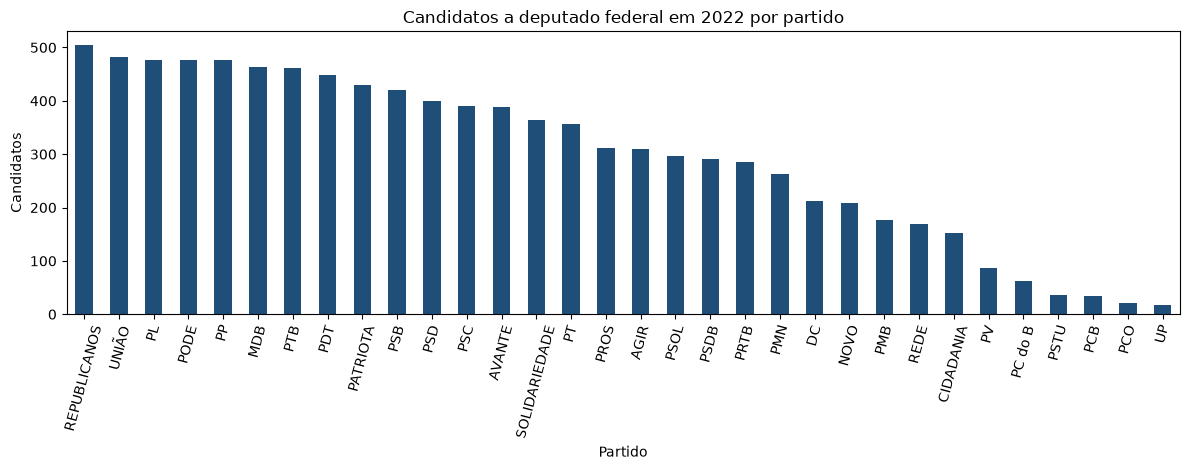

In [4]:
candidatos_2022 = carregar_candidatos(2022)
print(f"{formatar_inteiro(len(candidatos_2022))} candidaturas aptas a deputado federal em 2022")
resumo_2022 = resumo_por_partido(candidatos_2022)
display(resumo_2022)
grafico_barras(resumo_2022, "Candidatos a deputado federal em 2022 por partido", "candidatos", "Candidatos")
display(colunas_para_exibir(candidatos_2022))

## Deputados federais em exercício, por partido

Esta lista vem da Câmara, não do resultado de 2022. Ela já inclui suplentes em exercício e o partido atual de cada parlamentar.

Consultando a Câmara dos Deputados...
Fichas consultadas: 100 de 513
Fichas consultadas: 200 de 513
Fichas consultadas: 300 de 513
Fichas consultadas: 400 de 513
Fichas consultadas: 500 de 513
Fichas consultadas: 513 de 513
Tabela salva em C:\Users\Luiz\Documents\analise-eleitoral\dados\processados\deputados_atuais.csv
513 deputados em exercício


,partido,deputados
0,PL,98
1,PT,65
2,UNIÃO,52
3,PSD,48
4,PP,46
5,REPUBLICANOS,42
6,MDB,38
7,PODE,27
8,PSB,17
9,PSDB,17


,partido,uf,nome,nome_eleitoral,situacao
0,AVANTE,BA,Neto Carletto,Neto Carletto,Exercício
1,AVANTE,BA,Pastor Sargento Isidório,Pastor Sargento Isidório,Exercício
2,AVANTE,MA,Duarte Jr.,Duarte Jr.,Exercício
3,AVANTE,MG,Luis Tibé,Luis Tibé,Exercício
4,AVANTE,PE,Waldemar Oliveira,Waldemar Oliveira,Exercício
...,...,...,...,...,...
508,UNIÃO,SE,Yandra Moura,Yandra Moura,Exercício
509,UNIÃO,SP,Alexandre Leite,Alexandre Leite,Exercício
510,UNIÃO,SP,Delegado da Cunha,Delegado da Cunha,Exercício
511,UNIÃO,SP,Fausto Pinato,Fausto Pinato,Exercício


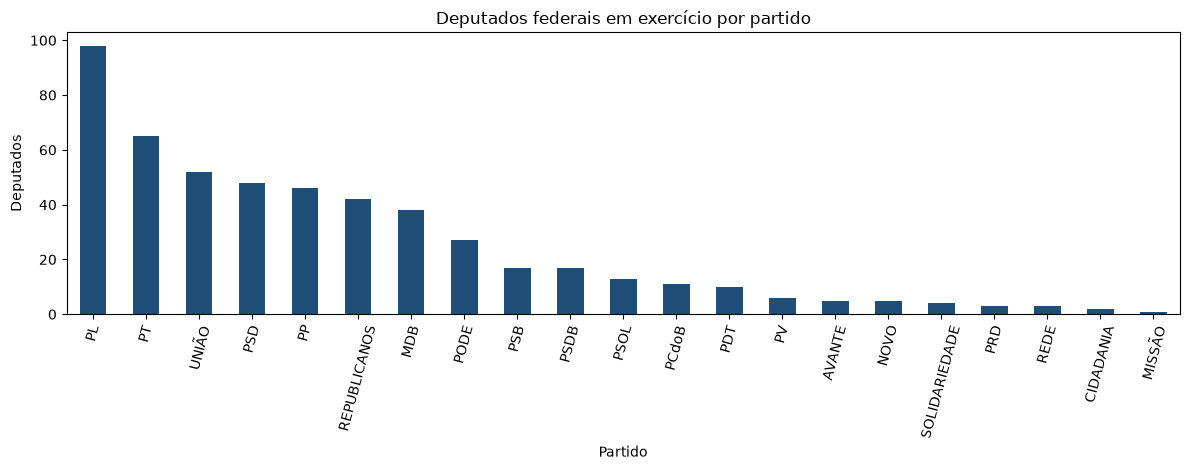

In [5]:
deputados_atuais = carregar_deputados_atuais()
print(f"{formatar_inteiro(len(deputados_atuais))} deputados em exercício")
resumo_deputados = resumo_por_partido(deputados_atuais, nome_contagem="deputados")
display(resumo_deputados)
grafico_barras(resumo_deputados, "Deputados federais em exercício por partido", "deputados", "Deputados")
display(deputados_atuais[["partido", "uf", "nome", "nome_eleitoral", "situacao"]])

## Candidatos a deputado federal em 2026, por partido

In [6]:
candidatos_2026 = carregar_candidatos(2026)
print(f"{formatar_inteiro(len(candidatos_2026))} candidaturas aptas a deputado federal em 2026")
resumo_2026 = resumo_por_partido(candidatos_2026)
display(resumo_2026)
grafico_barras(resumo_2026, "Candidatos a deputado federal em 2026 por partido", "candidatos", "Candidatos")
display(colunas_para_exibir(candidatos_2026))

ErroFonte: O TSE recusou o download (403). Baixe manualmente https://cdn.tse.jus.br/estatistica/sead/odsele/consulta_cand/consulta_cand_2026.zip e salve o arquivo em C:\Users\Luiz\Documents\analise-eleitoral\dados\brutos\consulta_cand_2026.zip.

## Quem saiu e quem entrou

A comparação principal é entre as duas listas de candidaturas aptas. A mesma pessoa é reconhecida pelo título de eleitor, pelo CPF ou, na falta dos dois, pelo nome civil com UF e data de nascimento.

- **Saiu:** estava na disputa de 2022 e não está na de 2026.
- **Entrou:** está na disputa de 2026 e não estava na de 2022.
- **Continua:** está nas duas. Quando o partido mudou, a pessoa aparece também na tabela de troca.

Em seguida há dois recortes mais estreitos: eleitos em 2022 que não concorrem em 2026, e deputados em exercício que não aparecem na disputa de 2026.

In [ ]:
comparacao = comparar_disputas(candidatos_2022, candidatos_2026)
print(f"Saíram: {formatar_inteiro(len(comparacao.sairam))}")
print(f"Entraram: {formatar_inteiro(len(comparacao.entraram))}")
print(f"Continuam: {formatar_inteiro(len(comparacao.continuam))}")
print(f"Trocaram de partido: {formatar_inteiro(len(comparacao.mudaram_de_partido))}")
print(f"Eleitos em 2022 que não concorrem em 2026: {formatar_inteiro(len(comparacao.eleitos_que_nao_concorrem))}")

display(comparacao.resumo_sairam)
display(colunas_para_exibir(comparacao.sairam))
display(comparacao.resumo_entraram)
display(colunas_para_exibir(comparacao.entraram))

colunas_troca = ["uf", "nome_urna", "nome", "partido_2022", "partido_2026"]
display(comparacao.mudaram_de_partido[colunas_troca])
display(colunas_para_exibir(comparacao.eleitos_que_nao_concorrem))

mandato = cruzar_deputados(deputados_atuais, candidatos_2026)
print(f"Deputados em exercício que não estão na disputa de 2026: {formatar_inteiro(len(mandato.fora_da_disputa_2026))}")
print(f"Deputados em exercício que estão na disputa de 2026: {formatar_inteiro(len(mandato.na_disputa_2026))}")
display(mandato.resumo_fora)
display(mandato.fora_da_disputa_2026[["partido", "uf", "nome", "nome_eleitoral"]])

## Votos de 2022 por candidato

Soma dos votos nominais do 1º turno, a partir da votação por município e zona. O arquivo é grande na primeira leitura.

In [ ]:
votos_2022 = carregar_votos(candidatos_2022)
print(f"Total de votos nominais: {formatar_inteiro(votos_2022['votos'].sum())}")
resumo_votos = resumo_por_partido(votos_2022, valor="votos")
display(resumo_votos)
grafico_barras(resumo_votos, "Votos nominais de deputado federal em 2022 por partido", "votos", "Votos")
display(colunas_para_exibir(votos_2022, ["partido", "uf", "numero", "nome_urna", "nome", "resultado", "votos"]))

## Gasto com publicidade em 2022, por candidato

O valor é a soma das **despesas contratadas** classificadas pelo TSE como publicidade, propaganda, impulsionamento ou páginas na internet. É o conceito divulgado na prestação de contas, não o valor pago em outra rubrica.

Candidato com R$ 0,00 não declarou despesa contratada nesses tipos.

In [ ]:
publicidade_2022 = carregar_gastos_publicidade(2022, candidatos_2022)
print(publicidade_2022.texto)
display(tabela_reais(publicidade_2022.categorias, "valor"))
display(tabela_reais(publicidade_2022.por_partido))
grafico_barras(
    publicidade_2022.por_partido,
    "Publicidade contratada em 2022 por partido",
    "gasto_publicidade",
    "Reais",
)
display(
    tabela_reais(
        colunas_para_exibir(
            publicidade_2022.por_candidato,
            ["partido", "uf", "numero", "nome_urna", "nome", "resultado", "gasto_publicidade"],
        )
    )
)

## Gasto com publicidade em 2026, até 28/09/2026

Entra despesa contratada com data até 28 de setembro de 2026. Lançamento sem data ou com data posterior fica de fora da soma. A frase impressa pela célula informa a data de geração do arquivo do TSE e o período coberto.

In [ ]:
publicidade_2026 = carregar_gastos_publicidade(2026, candidatos_2026, data_corte=DATA_CORTE_2026)
print(publicidade_2026.texto)
display(tabela_reais(publicidade_2026.categorias, "valor"))
display(tabela_reais(publicidade_2026.por_partido))
grafico_barras(
    publicidade_2026.por_partido,
    "Publicidade contratada em 2026 até 28/09/2026, por partido",
    "gasto_publicidade",
    "Reais",
)
display(
    tabela_reais(
        colunas_para_exibir(
            publicidade_2026.por_candidato,
            ["partido", "uf", "numero", "nome_urna", "nome", "gasto_publicidade"],
        )
    )
)